# Анализ результатов бенчмарков TSEdge

Этот notebook сравнивает несколько способов хранения числовых временных рядов:

- TSEdge;
- raw binary;
- CSV;
- SQLite, если доступны результаты бенчмарка.

Сравнение выполняется на одинаковых наборах данных и при одинаковом количестве точек. Notebook предназначен для воспроизводимого анализа результатов в дипломной работе.


## 1. Методика тестирования

Наборы данных:

1. `smooth` - плавно изменяющиеся значения с небольшим шумом.
2. `noisy` - шумные случайные значения.
3. `step` - ступенчатые значения, которые повторяются на интервалах.

Метрики:

- `write_seconds`: время записи.
- `write_points_per_sec`: скорость записи, точек/с.
- `read_seconds`: время чтения.
- `read_points_per_sec`: скорость чтения, точек/с.
- `avg_seconds`: время агрегирующего запроса.
- `size_bytes`: размер хранилища.
- `raw_size_bytes`: размер несжатого бинарного представления, 16 байт на точку.
- `compression_ratio`: коэффициент сжатия, `raw_size_bytes / size_bytes`; значения больше 1 означают размер меньше raw binary.


In [1]:
from pathlib import Path
import subprocess
import platform
import datetime as dt

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "benchmark_results"
FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_COLUMNS = [
    "system", "dataset", "points", "write_seconds", "write_points_per_sec",
    "read_seconds", "read_points_per_sec", "avg_seconds", "size_bytes",
    "raw_size_bytes", "compression_ratio",
]

OPTIONAL_COLUMNS = [
    "block_count", "decoded_block_count", "skipped_block_count",
]

print(f"Корень репозитория: {ROOT}")
print(f"Директория результатов бенчмарков: {RESULTS_DIR}")

Корень репозитория: /Users/liminfinity/projects/tsedge
Директория результатов бенчмарков: /Users/liminfinity/projects/tsedge/benchmark_results


## 2. Опционально: запуск бенчмарков из notebook

Эта ячейка по умолчанию отключена. Установите `RUN_BENCHMARKS = True`, чтобы запустить benchmark-бинарники из корня репозитория. Если бинарник отсутствует, notebook выведет сообщение и продолжит работу.


In [2]:
RUN_BENCHMARKS = False
POINTS = 1_000_000

benchmark_commands = [
    (ROOT / "build" / "tsedge_bench", RESULTS_DIR / "tsedge.csv"),
    (ROOT / "build" / "file_bench", RESULTS_DIR / "file.csv"),
    (ROOT / "build" / "sqlite_bench", RESULTS_DIR / "sqlite.csv"),
]

if RUN_BENCHMARKS:
    for binary, output_csv in benchmark_commands:
        if not binary.exists():
            print(f"Пропущен отсутствующий benchmark-бинарник: {binary}")
            continue
        cmd = [str(binary), str(POINTS), str(output_csv)]
        print("Запуск:", " ".join(cmd))
        completed = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
        print(completed.stdout)
        if completed.returncode != 0:
            print(completed.stderr)
else:
    print("Запуск бенчмарков отключен. Установите RUN_BENCHMARKS = True, чтобы запустить их из notebook.")

Запуск бенчмарков отключен. Установите RUN_BENCHMARKS = True, чтобы запустить их из notebook.


## 3. Информация об окружении

Информацию об окружении нужно сохранять вместе с результатами, потому что производительность зависит от устройства, компилятора, файловой системы и накопителя.


In [3]:
def cpu_info():
    candidates = []
    try:
        candidates.append(platform.processor())
    except Exception:
        pass
    if platform.system() == "Darwin":
        try:
            result = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True)
            if result.returncode == 0:
                candidates.append(result.stdout.strip())
        except Exception:
            pass
    if platform.system() == "Linux":
        cpuinfo = Path("/proc/cpuinfo")
        if cpuinfo.exists():
            for line in cpuinfo.read_text(errors="ignore").splitlines():
                if line.lower().startswith("model name"):
                    candidates.append(line.split(":", 1)[1].strip())
                    break
    return next((value for value in candidates if value), "неизвестно")

environment = pd.DataFrame([
    {"property": "analysis_time", "value": dt.datetime.now().isoformat(timespec="seconds")},
    {"property": "os", "value": platform.system()},
    {"property": "platform", "value": platform.platform()},
    {"property": "python_version", "value": platform.python_version()},
    {"property": "cpu", "value": cpu_info()},
])
environment

,property,value
0,analysis_time,2026-05-26T20:32:25
1,os,Darwin
2,platform,macOS-26.3.1-arm64-arm-64bit-Mach-O
3,python_version,3.14.4
4,cpu,arm


## 4. Загрузка результатов бенчмарков

Notebook читает CSV-файлы из `benchmark_results/`:

- `benchmark_results/tsedge.csv`
- `benchmark_results/file.csv`
- `benchmark_results/sqlite.csv`

Если файл отсутствует, notebook выводит предупреждение и продолжает анализ доступных данных.


In [4]:
COLUMN_ALIASES = {
    "aggregate_seconds": "avg_seconds",
    "db_size_bytes": "size_bytes",
}

def normalize_columns(df):
    df = df.rename(columns={old: new for old, new in COLUMN_ALIASES.items() if old in df.columns})
    for column in EXPECTED_COLUMNS:
        if column not in df.columns:
            df[column] = pd.NA
    available_optional = [column for column in OPTIONAL_COLUMNS if column in df.columns]
    numeric_columns = [c for c in EXPECTED_COLUMNS + available_optional if c not in {"system", "dataset"}]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    return df[EXPECTED_COLUMNS + available_optional]

def load_result_file(path):
    if not path.exists():
        print(f"Предупреждение: CSV-файл с результатами бенчмарков не найден: {path}")
        return pd.DataFrame(columns=EXPECTED_COLUMNS)
    loaded = pd.read_csv(path)
    return normalize_columns(loaded)

files = [RESULTS_DIR / "tsedge.csv", RESULTS_DIR / "file.csv", RESULTS_DIR / "sqlite.csv"]
frames = [load_result_file(path) for path in files]
results = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=EXPECTED_COLUMNS)
if not results.empty:
    results = results.sort_values(["points", "dataset", "system"], kind="stable").reset_index(drop=True)

print(f"Загружено строк: {len(results)}")

Загружено строк: 20


## 5. Просмотр исходных данных

Таблица ниже объединяет все доступные результаты бенчмарков и сортирует их по количеству точек, набору данных и системе.


In [5]:
if results.empty:
    print("CSV-файлы с результатами бенчмарков не найдены. Сначала запустите бенчмарки или включите RUN_BENCHMARKS выше.")
else:
    display(results)
    coverage = results.groupby("dataset")["system"].apply(lambda values: ", ".join(sorted(values.dropna().unique())))
    display(coverage.to_frame("systems_available"))

,system,dataset,points,write_seconds,write_points_per_sec,read_seconds,read_points_per_sec,avg_seconds,size_bytes,raw_size_bytes,compression_ratio
0,csv,constant,1000000,0.125338,7978426.34,0.024112,41473125.42,0.113892,17000016,16000000,0.941176
1,raw_binary,constant,1000000,0.064085,15604275.57,0.044792,22325415.25,0.044965,16000000,16000000,1.000000
2,sqlite,constant,1000000,0.502776,1988957.31,0.065293,15315577.47,0.053542,33292288,16000000,0.480592
3,tsedge,constant,1000000,24.331234,41099.44,0.011519,86813091.47,0.000244,2022902,16000000,7.909429
4,csv,irregular_timestamps,1000000,0.359814,2779213.70,0.028809,34711374.92,0.174267,32889023,16000000,0.486485
5,raw_binary,irregular_timestamps,1000000,0.070634,14157487.89,0.045106,22169999.55,0.044818,16000000,16000000,1.000000
6,sqlite,irregular_timestamps,1000000,0.523812,1909081.88,0.133022,7517553.49,0.119693,40386560,16000000,0.396171
7,tsedge,irregular_timestamps,1000000,25.208692,39668.86,0.024543,40744815.24,0.000562,10087280,16000000,1.586156
8,csv,noisy,1000000,0.360029,2777554.03,0.031439,31807627.46,0.179605,33999647,16000000,0.470593
9,raw_binary,noisy,1000000,0.065951,15162772.36,0.046549,21482738.62,0.046062,16000000,16000000,1.000000


,systems_available
dataset,
constant,"csv, raw_binary, sqlite, tsedge"
irregular_timestamps,"csv, raw_binary, sqlite, tsedge"
noisy,"csv, raw_binary, sqlite, tsedge"
smooth,"csv, raw_binary, sqlite, tsedge"
step,"csv, raw_binary, sqlite, tsedge"


## 6. Сводные таблицы

Эти сводные таблицы позволяют быстро сравнить системы на каждом наборе данных.


In [6]:
def pivot_metric(df, metric):
    if df.empty or metric not in df.columns:
        return pd.DataFrame()
    return df.pivot_table(index="dataset", columns="system", values=metric, aggfunc="mean")

summary_tables = {
    "Размер хранилища, байт": pivot_metric(results, "size_bytes"),
    "Коэффициент сжатия": pivot_metric(results, "compression_ratio"),
    "Скорость записи, точек/с": pivot_metric(results, "write_points_per_sec"),
    "Скорость чтения, точек/с": pivot_metric(results, "read_points_per_sec"),
    "Время агрегирующего запроса, с": pivot_metric(results, "avg_seconds"),
}

for title, table in summary_tables.items():
    print(title)
    display(table if not table.empty else pd.DataFrame({"message": ["недостаточно данных"]}))

Размер хранилища, байт


system,csv,raw_binary,sqlite,tsedge
dataset,,,,
constant,17000016.0,16000000.0,33292288.0,2022902.0
irregular_timestamps,32889023.0,16000000.0,40386560.0,10087280.0
noisy,33999647.0,16000000.0,40386560.0,10020772.0
smooth,32889006.0,16000000.0,40386560.0,9045379.0
step,17000016.0,16000000.0,33292288.0,2026344.0


Коэффициент сжатия


system,csv,raw_binary,sqlite,tsedge
dataset,,,,
constant,0.941176,1.0,0.480592,7.909429
irregular_timestamps,0.486485,1.0,0.396171,1.586156
noisy,0.470593,1.0,0.396171,1.596683
smooth,0.486485,1.0,0.396171,1.768859
step,0.941176,1.0,0.480592,7.895994


Скорость записи, точек/с


system,csv,raw_binary,sqlite,tsedge
dataset,,,,
constant,7978426.34,15604275.57,1988957.31,41099.44
irregular_timestamps,2779213.70,14157487.89,1909081.88,39668.86
noisy,2777554.03,15162772.36,1920355.19,41943.24
smooth,2707129.22,13774104.68,1892000.81,42382.28
step,7999232.07,15319096.79,1920819.96,41764.55


Скорость чтения, точек/с


system,csv,raw_binary,sqlite,tsedge
dataset,,,,
constant,41473125.42,22325415.25,15315577.47,86813091.47
irregular_timestamps,34711374.92,22169999.55,7517553.49,40744815.24
noisy,31807627.46,21482738.62,14538264.71,46352090.48
smooth,33223695.13,21574507.56,14492123.53,45226357.92
step,41911148.36,22136627.26,15335306.48,86125226.12


Время агрегирующего запроса, с


system,csv,raw_binary,sqlite,tsedge
dataset,,,,
constant,0.113892,0.044965,0.053542,0.000244
irregular_timestamps,0.174267,0.044818,0.119693,0.000562
noisy,0.179605,0.046062,0.056458,0.000266
smooth,0.174431,0.046069,0.055803,0.000546
step,0.114502,0.044540,0.054482,0.000258


In [7]:
def tsedge_relative_table(df):
    if df.empty or "tsedge" not in set(df["system"]):
        return pd.DataFrame()
    rows = []
    for dataset, group in df.groupby("dataset"):
        by_system = group.set_index("system")
        if "tsedge" not in by_system.index:
            continue
        row = {"dataset": dataset}
        tsedge = by_system.loc["tsedge"]
        for system in ["raw_binary", "csv", "sqlite"]:
            if system in by_system.index:
                other = by_system.loc[system]
                if pd.notna(other["size_bytes"]) and other["size_bytes"] > 0:
                    row[f"size_reduction_vs_{system}"] = 1.0 - float(tsedge["size_bytes"]) / float(other["size_bytes"])
        if "sqlite" in by_system.index:
            sqlite = by_system.loc["sqlite"]
            if sqlite["write_points_per_sec"] > 0:
                row["write_speed_ratio_vs_sqlite"] = float(tsedge["write_points_per_sec"]) / float(sqlite["write_points_per_sec"])
            if sqlite["read_points_per_sec"] > 0:
                row["read_speed_ratio_vs_sqlite"] = float(tsedge["read_points_per_sec"]) / float(sqlite["read_points_per_sec"])
            if sqlite["avg_seconds"] > 0:
                row["aggregation_time_ratio_vs_sqlite"] = float(tsedge["avg_seconds"]) / float(sqlite["avg_seconds"])
        rows.append(row)
    return pd.DataFrame(rows)

relative = tsedge_relative_table(results)
display(relative if not relative.empty else pd.DataFrame({"message": ["недостаточно данных для сравнения TSEdge"]}))

,dataset,size_reduction_vs_raw_binary,size_reduction_vs_csv,size_reduction_vs_sqlite,write_speed_ratio_vs_sqlite,read_speed_ratio_vs_sqlite,aggregation_time_ratio_vs_sqlite
0,constant,0.873569,0.881006,0.939238,0.020664,5.668287,0.004557
1,irregular_timestamps,0.369545,0.693293,0.750232,0.020779,5.419957,0.004695
2,noisy,0.373702,0.705268,0.751879,0.021841,3.188282,0.004711
3,smooth,0.434664,0.724973,0.776030,0.022401,3.120754,0.009784
4,step,0.873354,0.880803,0.939135,0.021743,5.616140,0.004736


## 7. Графики

Каждый график сохраняется в PNG и SVG в директории `benchmark_results/figures/`. Для метрик, значения которых могут различаться на порядки, используется логарифмическая шкала.


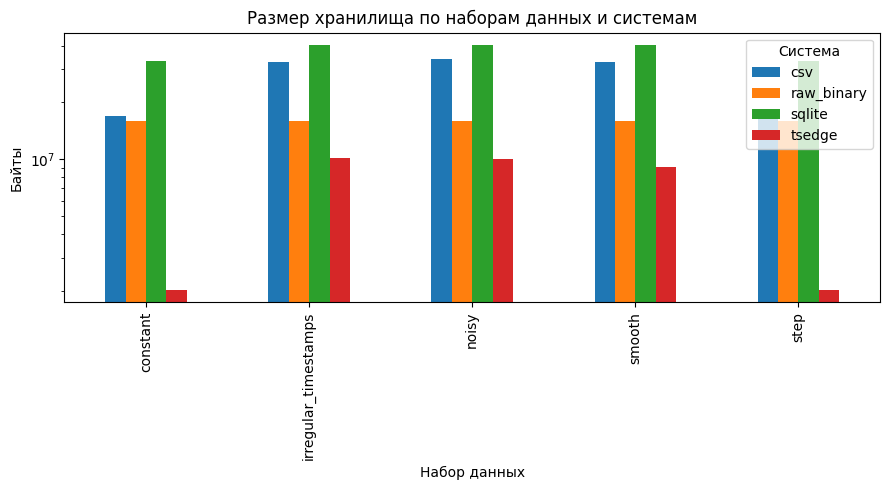

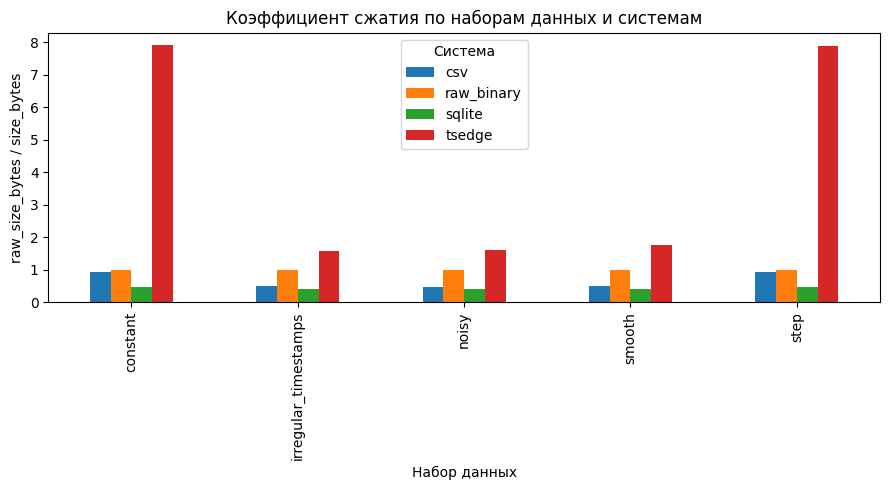

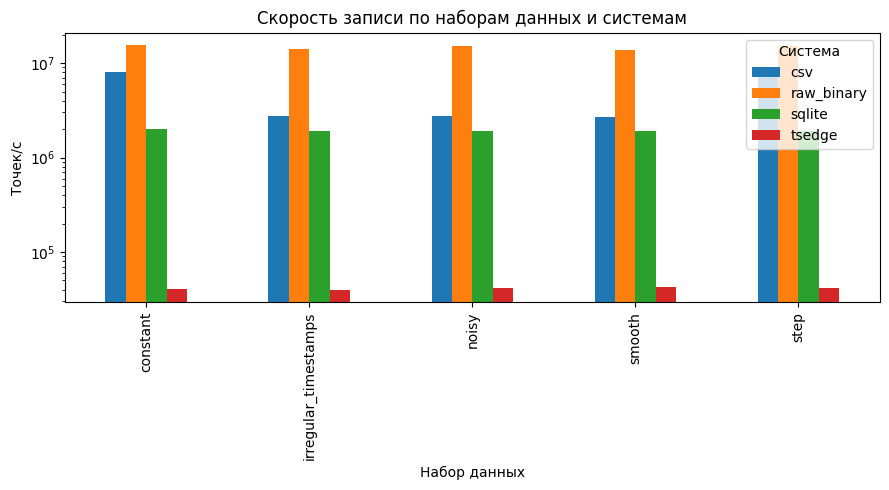

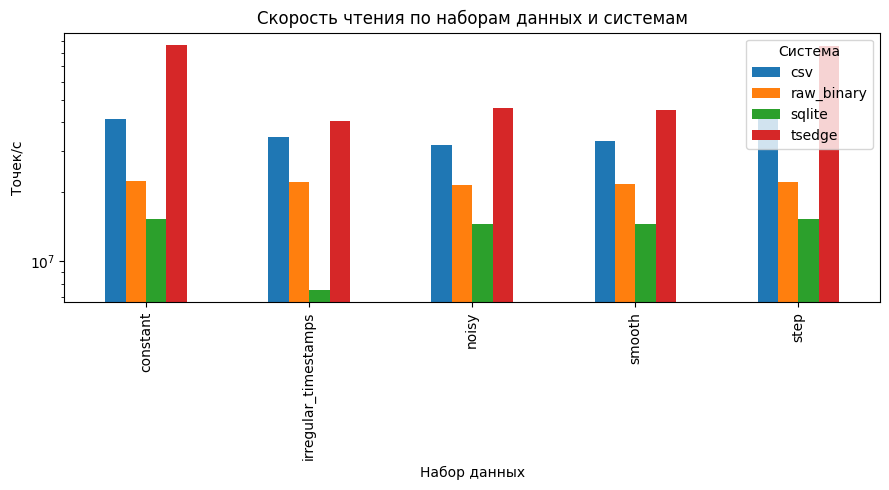

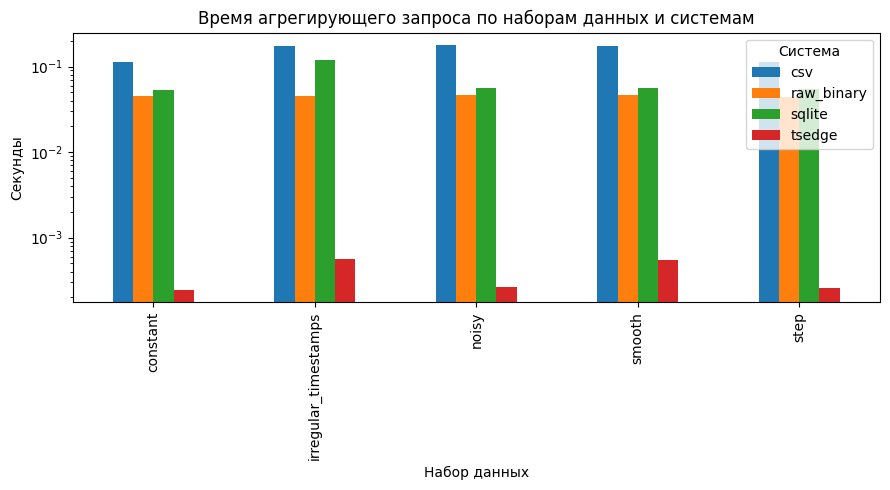

In [8]:
def save_plot(name):
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=160)
    plt.savefig(FIGURES_DIR / f"{name}.svg")
    plt.show()

def plot_metric(metric, title, ylabel, filename, logy=False):
    table = pivot_metric(results, metric)
    if table.empty:
        print(f"График пропущен: {title}; нет данных")
        return
    ax = table.plot(kind="bar", figsize=(9, 5), logy=logy)
    ax.set_title(title)
    ax.set_xlabel("Набор данных")
    ax.set_ylabel(ylabel)
    ax.legend(title="Система")
    save_plot(filename)

plot_metric("size_bytes", "Размер хранилища по наборам данных и системам", "Байты", "storage_size", logy=True)
plot_metric("compression_ratio", "Коэффициент сжатия по наборам данных и системам", "raw_size_bytes / size_bytes", "compression_ratio")
plot_metric("write_points_per_sec", "Скорость записи по наборам данных и системам", "Точек/с", "write_throughput", logy=True)
plot_metric("read_points_per_sec", "Скорость чтения по наборам данных и системам", "Точек/с", "read_throughput", logy=True)
plot_metric("avg_seconds", "Время агрегирующего запроса по наборам данных и системам", "Секунды", "aggregation_time", logy=True)

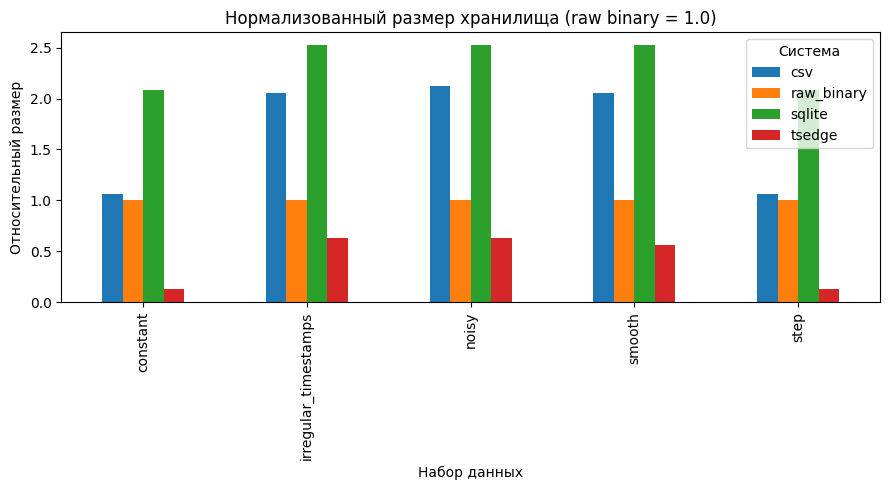

In [9]:
def plot_normalized_vs_raw():
    if results.empty or "raw_binary" not in set(results["system"]):
        print("Нормализованный график пропущен: базовая система raw_binary недоступна")
        return
    table = pivot_metric(results, "size_bytes")
    if table.empty or "raw_binary" not in table.columns:
        print("Нормализованный график пропущен: нет столбца размера для raw_binary")
        return
    normalized = table.div(table["raw_binary"], axis=0)
    ax = normalized.plot(kind="bar", figsize=(9, 5))
    ax.set_title("Нормализованный размер хранилища (raw binary = 1.0)")
    ax.set_xlabel("Набор данных")
    ax.set_ylabel("Относительный размер")
    ax.legend(title="Система")
    save_plot("normalized_storage_vs_raw")

plot_normalized_vs_raw()

## 8. Интерпретация результатов

Текстовые выводы ниже формируются только на основе доступных строк benchmark-результатов. Перед переносом в диплом их следует проверить и при необходимости уточнить.


In [10]:
def interpret(df):
    if df.empty:
        return ["CSV-файлы с результатами бенчмарков не найдены. Сначала запустите benchmark-утилиты."]
    lines = []
    tsedge_rows = df[df["system"] == "tsedge"]
    if not tsedge_rows.empty:
        best = tsedge_rows.loc[tsedge_rows["compression_ratio"].idxmax()]
        worst = tsedge_rows.loc[tsedge_rows["compression_ratio"].idxmin()]
        lines.append(f"Наилучший коэффициент сжатия TSEdge показал на наборе данных {best['dataset']} ({best['compression_ratio']:.3f}).")
        lines.append(f"Наихудший коэффициент сжатия TSEdge показал на наборе данных {worst['dataset']} ({worst['compression_ratio']:.3f}).")
    largest = df.loc[df["size_bytes"].idxmax()]
    lines.append(f"Наибольший измеренный размер хранилища: {largest['system']} на наборе данных {largest['dataset']} ({largest['size_bytes']:.0f} байт).")
    if "sqlite" in set(df["system"]) and not tsedge_rows.empty:
        merged = tsedge_rows.merge(df[df["system"] == "sqlite"], on="dataset", suffixes=("_tsedge", "_sqlite"))
        if not merged.empty:
            write_ratio = (merged["write_points_per_sec_tsedge"] / merged["write_points_per_sec_sqlite"]).mean()
            read_ratio = (merged["read_points_per_sec_tsedge"] / merged["read_points_per_sec_sqlite"]).mean()
            lines.append(f"По доступным наборам данных средняя скорость записи TSEdge относительно SQLite в этом запуске составляет {write_ratio:.3f}x.")
            lines.append(f"По доступным наборам данных средняя скорость чтения TSEdge относительно SQLite в этом запуске составляет {read_ratio:.3f}x.")
    elif "sqlite" not in set(df["system"]):
        lines.append("Результаты SQLite недоступны, поэтому сравнение с SQLite не выполнялось.")
    lines.append("Ожидаемо, набор noisy обычно сжимается хуже, чем smooth или step, потому что изменения значений менее предсказуемы.")
    return lines

for line in interpret(results):
    print("-", line)

- Наилучший коэффициент сжатия TSEdge показал на наборе данных constant (7.909).
- Наихудший коэффициент сжатия TSEdge показал на наборе данных irregular_timestamps (1.586).
- Наибольший измеренный размер хранилища: sqlite на наборе данных irregular_timestamps (40386560 байт).
- По доступным наборам данных средняя скорость записи TSEdge относительно SQLite в этом запуске составляет 0.021x.
- По доступным наборам данных средняя скорость чтения TSEdge относительно SQLite в этом запуске составляет 4.603x.
- Ожидаемо, набор noisy обычно сжимается хуже, чем smooth или step, потому что изменения значений менее предсказуемы.


## 9. Таблицы для дипломной работы

Следующие таблицы экспортируются в CSV и могут быть использованы или адаптированы для дипломной работы.


In [11]:
def build_diploma_tables(df):
    if df.empty:
        empty = pd.DataFrame()
        return empty, empty, empty

    main = df.copy()
    main["size_mb"] = main["size_bytes"] / (1024 * 1024)
    main["avg_ms"] = main["avg_seconds"] * 1000
    main = main[["dataset", "system", "points", "size_mb", "compression_ratio", "write_points_per_sec", "read_points_per_sec", "avg_ms"]]

    rows = []
    for metric, direction in [("size_bytes", "min"), ("compression_ratio", "max"), ("write_points_per_sec", "max"), ("read_points_per_sec", "max"), ("avg_seconds", "min")]:
        if metric not in df.columns or df[metric].dropna().empty:
            continue
        idx = df[metric].idxmin() if direction == "min" else df[metric].idxmax()
        best = df.loc[idx]
        tsedge_values = df[df["system"] == "tsedge"][metric]
        tsedge_value = tsedge_values.mean() if not tsedge_values.empty else pd.NA
        rows.append({"metric": metric, "best_system": best["system"], "tsedge_value": tsedge_value, "comment": "Лучшая система выбрана только среди доступных результатов бенчмарков."})
    relative_table = pd.DataFrame(rows)

    characters = {
        "smooth": ("плавно изменяющиеся значения", "обычно хорошо сжимается, потому что изменения постепенные"),
        "noisy": ("случайные значения", "обычно сжимается хуже, потому что значения непредсказуемы"),
        "step": ("повторяющиеся ступенчатые значения", "обычно хорошо сжимается, потому что многие значения повторяются"),
    }
    dataset_rows = []
    for dataset in sorted(df["dataset"].dropna().unique()):
        tsedge_row = df[(df["dataset"] == dataset) & (df["system"] == "tsedge")]
        observed = tsedge_row["compression_ratio"].iloc[0] if not tsedge_row.empty else pd.NA
        data_character, expected = characters.get(dataset, ("неизвестно", "ожидаемое поведение не задано"))
        dataset_rows.append({"dataset": dataset, "data_character": data_character, "expected_compression_behavior": expected, "observed_compression_ratio_for_tsedge": observed})
    dataset_table = pd.DataFrame(dataset_rows)
    return main, relative_table, dataset_table

diploma_main, diploma_relative, diploma_dataset = build_diploma_tables(results)

if results.empty:
    print("Данные недоступны; таблицы для дипломной работы не экспортированы.")
else:
    diploma_main.to_csv(RESULTS_DIR / "diploma_main_table.csv", index=False)
    diploma_relative.to_csv(RESULTS_DIR / "diploma_relative_table.csv", index=False)
    diploma_dataset.to_csv(RESULTS_DIR / "diploma_dataset_table.csv", index=False)
    display(diploma_main)
    display(diploma_relative)
    display(diploma_dataset)

,dataset,system,points,size_mb,compression_ratio,write_points_per_sec,read_points_per_sec,avg_ms
0,constant,csv,1000000,16.212479,0.941176,7978426.34,41473125.42,113.892
1,constant,raw_binary,1000000,15.258789,1.000000,15604275.57,22325415.25,44.965
2,constant,sqlite,1000000,31.750000,0.480592,1988957.31,15315577.47,53.542
3,constant,tsedge,1000000,1.929190,7.909429,41099.44,86813091.47,0.244
4,irregular_timestamps,csv,1000000,31.365417,0.486485,2779213.70,34711374.92,174.267
5,irregular_timestamps,raw_binary,1000000,15.258789,1.000000,14157487.89,22169999.55,44.818
6,irregular_timestamps,sqlite,1000000,38.515625,0.396171,1909081.88,7517553.49,119.693
7,irregular_timestamps,tsedge,1000000,9.619980,1.586156,39668.86,40744815.24,0.562
8,noisy,csv,1000000,32.424590,0.470593,2777554.03,31807627.46,179.605
9,noisy,raw_binary,1000000,15.258789,1.000000,15162772.36,21482738.62,46.062


,metric,best_system,tsedge_value,comment
0,size_bytes,tsedge,6.640535e+06,Лучшая система выбрана только среди доступных ...
1,compression_ratio,tsedge,4.151424e+00,Лучшая система выбрана только среди доступных ...
2,write_points_per_sec,raw_binary,4.137167e+04,Лучшая система выбрана только среди доступных ...
3,read_points_per_sec,tsedge,6.105232e+07,Лучшая система выбрана только среди доступных ...
4,avg_seconds,tsedge,3.752000e-04,Лучшая система выбрана только среди доступных ...


,dataset,data_character,expected_compression_behavior,observed_compression_ratio_for_tsedge
0,constant,неизвестно,ожидаемое поведение не задано,7.909429
1,irregular_timestamps,неизвестно,ожидаемое поведение не задано,1.586156
2,noisy,случайные значения,"обычно сжимается хуже, потому что значения неп...",1.596683
3,smooth,плавно изменяющиеся значения,"обычно хорошо сжимается, потому что изменения ...",1.768859
4,step,повторяющиеся ступенчатые значения,"обычно хорошо сжимается, потому что многие зна...",7.895994


## 10. Итоговый вывод

Если результаты бенчмарков доступны, используйте таблицы и интерпретацию выше, чтобы сформулировать аккуратный вывод для дипломной работы. Возможная структура:

> По результатам экспериментов TSEdge демонстрирует [кратко описать наблюдаемое сжатие и производительность по таблицам] на протестированных наборах данных. Результаты показывают, что наборы `smooth` и `step` в целом более благоприятны для реализованного lossless-сжатия, чем набор `noisy`. Сравнение с raw binary, CSV и SQLite следует интерпретировать только для использованного устройства, компилятора и накопителя; оно не означает, что TSEdge всегда быстрее или компактнее во всех сценариях.

Если данные не загружены, сначала запустите benchmark-утилиты и затем повторно выполните notebook.
